In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024_sample.csv
/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024_data_dictionary.csv
/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024.csv


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt

input_dir = Path("/kaggle/input")

for path in input_dir.rglob("*"):
    if path.is_file():
        print(path)

/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024_sample.csv
/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024_data_dictionary.csv
/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024.csv


## Data dictionary

Before loading the large flight dataset, I inspect its data dictionary
to understand the available variables, expected data types, missing-value
percentages, and example values.

In [3]:
dictionary_path = Path("/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024_data_dictionary.csv")
data_dictionary = pd.read_csv(dictionary_path)

print(data_dictionary["column"])
print(data_dictionary.shape)
print(data_dictionary)

0                    year
1                   month
2            day_of_month
3             day_of_week
4                 fl_date
5       op_unique_carrier
6       op_carrier_fl_num
7                  origin
8        origin_city_name
9         origin_state_nm
10                   dest
11         dest_city_name
12          dest_state_nm
13           crs_dep_time
14               dep_time
15              dep_delay
16               taxi_out
17             wheels_off
18              wheels_on
19                taxi_in
20           crs_arr_time
21               arr_time
22              arr_delay
23              cancelled
24      cancellation_code
25               diverted
26       crs_elapsed_time
27    actual_elapsed_time
28               air_time
29               distance
30          carrier_delay
31          weather_delay
32              nas_delay
33         security_delay
34    late_aircraft_delay
Name: column, dtype: object
(35, 4)
                 column           dtype  null_pct     

#  Loading and reading to understand Data_sample 

In [4]:
data_sample = Path("/kaggle/input/datasets/hrishitpatil/flight-data-2024/flight_data_2024_sample.csv")
flights = pd.read_csv(data_sample)
missing_arr_delay = flights[flights["arr_delay"].isna()]
print(missing_arr_delay[["cancelled", "diverted"]].value_counts())
early_arr = (flights["arr_delay"] < 0).sum()
on_time_or_minor_delay = ((flights["arr_delay"] >= 0) & (flights["arr_delay"] < 15)).sum()
significant_delay = (flights["arr_delay"] >= 15).sum()
missingarr_delay = flights["arr_delay"].isna().sum()
total_delay_arr = early_arr + on_time_or_minor_delay + significant_delay + missingarr_delay
assert total_delay_arr == len(flights)
print(flights.shape)
print(early_arr, on_time_or_minor_delay, significant_delay, missingarr_delay, total_delay_arr)
#print(flights.isna().sum())
#print(flights["cancelled"].value_counts())
#print(flights["diverted"].value_counts())

cancelled  diverted
1          0           122
0          1            42
Name: count, dtype: int64
(10000, 35)
6092 1625 2119 164 10000


# using matplolib for visualization of the data for even a better understanding

0.900      47.000
0.990     217.000
0.995     310.075
1.000    2014.000
Name: arr_delay, dtype: float64


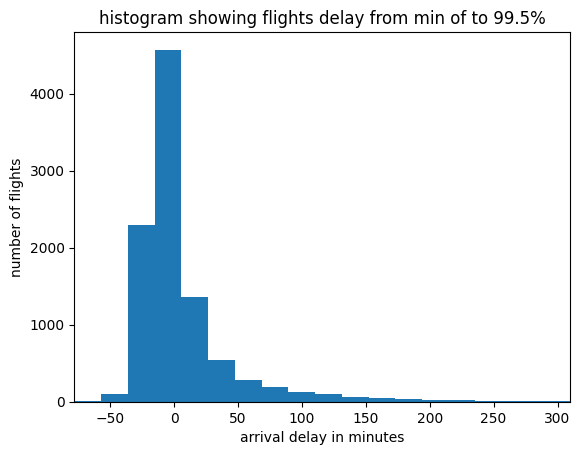

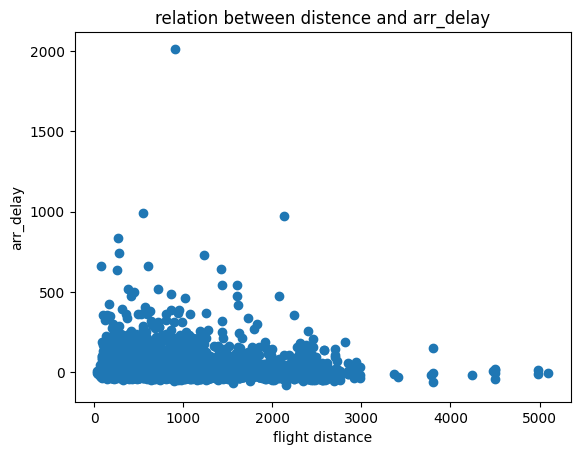

                  arr_delay                   significant_delay1
                      count median       mean               mean
op_unique_carrier                                               
9E                      272  -11.0   4.077206           0.139706
AA                     1360   -4.0  16.198529           0.280882
AS                      315   -4.0   3.104762                0.2
B6                      328   -6.0  11.411585           0.268293
DL                     1443   -8.0   3.545392           0.174636
F9                      288   -4.0  15.899306           0.291667
G4                      170   -6.5   9.729412           0.276471
HA                       94   -1.0   0.425532           0.117021
MQ                      399   -6.0   4.892231           0.192982
NK                      350   -6.5   8.465714               0.24
OH                      316   -5.0  13.572785           0.262658
OO                     1067   -7.0   9.117151           0.196813
UA                     10

In [5]:
categories = np.array(["early_arr", "on_time_or_minor_delay", "significant_delay", "missingarr_delay"])
counts = np.array([early_arr, on_time_or_minor_delay, significant_delay, missingarr_delay])
#plt.bar(categories, counts, color = 'purple')
#plt.show()

#i will now keep only valid_delay_arr to plot the data for linear regression
valid_arr_delay = flights["arr_delay"].dropna()
#print(valid_arr_delay.describe())
plt.hist(valid_arr_delay, bins = 100)
print(valid_arr_delay.quantile([0.90, 0.99, 0.995, 1]))
plt.xlim(-78, 310.075)
plt.title("histogram showing flights delay from min of to 99.5%")
plt.xlabel("arrival delay in minutes")
plt.ylabel("number of flights")
plt.show()
#here i worked on agg() to get some usfile statistcs for my data to help understand relations
#and pattrens related to delays 
flights["significant_delay1"] = (flights["arr_delay"].dropna() >= 15)

largest_delays = flights.sort_values(by = "arr_delay", ascending=False)

largest_delays_view = largest_delays.iloc[:10][["fl_date","op_unique_carrier","origin","dest","arr_delay"]]

delay_stat = flights.groupby('op_unique_carrier').agg({"arr_delay": ["count","median","mean"],
                                                      "significant_delay1" : "mean"})
#ploting the relation between distance and delays using scatter
plt.scatter(flights["distance"],flights["arr_delay"])
plt.title("relation between distence and arr_delay")
plt.xlabel("flight distance")
plt.ylabel("arr_delay")
plt.show()
print(delay_stat)
print(flights.groupby('op_unique_carrier')['arr_delay'].median().sort_values())


# STUDYING MORE RELATIONS BETWEEN FEATURES AND AEE_DELAYS

               arr_delay                   large_delay
                   count       mean median        mean
departure_hour                                        
0                     13   7.230769   12.0    0.461538
1                      7 -11.571429  -15.0    0.142857
2                      2  -5.500000   -5.5         0.0
3                      3 -11.000000  -12.0         0.0
4                      1  43.000000   43.0         1.0
5                    278  -1.809353  -12.0    0.100719
6                    682   3.511730   -9.0    0.130499
7                    689   4.552975   -9.0    0.148041
8                    667  -1.392804   -8.0    0.142429
9                    546   3.021978   -7.0    0.175824
10                   629   4.968203   -8.0     0.17965
11                   569   0.715290   -7.0    0.158172
12                   632   6.764241   -7.0    0.200949
13                   607   2.716639   -5.0    0.187809
14                   562   6.491103   -5.0    0.234875
15        

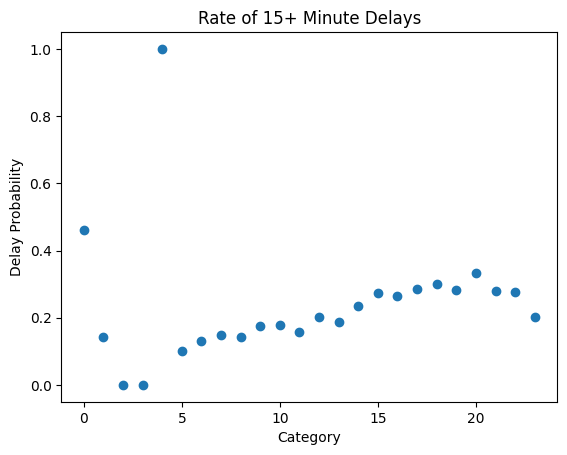

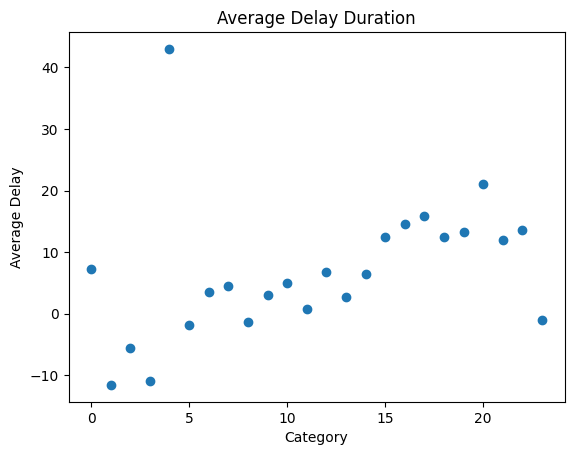

In [6]:
flights["departure_hour"] = (flights["crs_dep_time"] // 100)
def summarize_delay_by(df, delay_parameter):
    # getting data ready to plot the first large delay corresponding to the parameter we need to explore
    df["large_delay"] = (df["arr_delay"].dropna() >= 15)
    delay_stats = df.groupby(delay_parameter).agg({"arr_delay" : ["count", "mean", "median"],
                                                      "large_delay" : "mean"})
    large_delays_rate = delay_stats[("large_delay", "mean")]
    #working on the variable for the avarege delay
    avarege_delays_rate = delay_stats[('arr_delay', 'mean')]
    return delay_stats, large_delays_rate, avarege_delays_rate

def ploting_summarize(flight_stats,plot_type):
    print(flight_stats[0])
    get_plot_type = getattr(plt, plot_type)
    get_plot_type(flight_stats[0].index, flight_stats[1])
    #plt.plot_type(flight_stats[0].index, flight_stats[1])
    plt.title("Rate of 15+ Minute Delays")
    plt.xlabel("Category")
    plt.ylabel("Delay Probability")
    plt.show()

# Plotting the hours (the index) against the average delays
    #plt.plot_type(flight_stats[2].index, flight_stats[2])
    get_plot_type(flight_stats[2].index, flight_stats[2])
    plt.title("Average Delay Duration")
    plt.xlabel("Category")
    plt.ylabel("Average Delay")
    plt.show()
    return 
#using the functions to find and plot the relation between the category targeted and the arr_delay 
#,plus large delay'
flight_stats_hour = summarize_delay_by(flights, "departure_hour")
plotting_show = ploting_summarize(flight_stats_hour,"scatter")

            arr_delay                   large_delay
                count       mean median        mean
day_of_week                                        
1                1530   6.427451   -7.0    0.201307
2                1376   3.092297   -8.0     0.18314
3                1298   4.640986   -6.5    0.187211
4                1521   8.888231   -4.0    0.239316
5                1437   9.984690   -5.0    0.240779
6                1279   9.565285   -7.0    0.217357
7                1395  10.035125   -4.0    0.235125


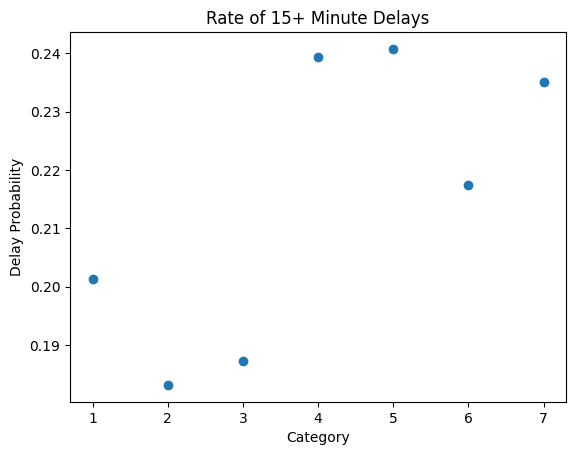

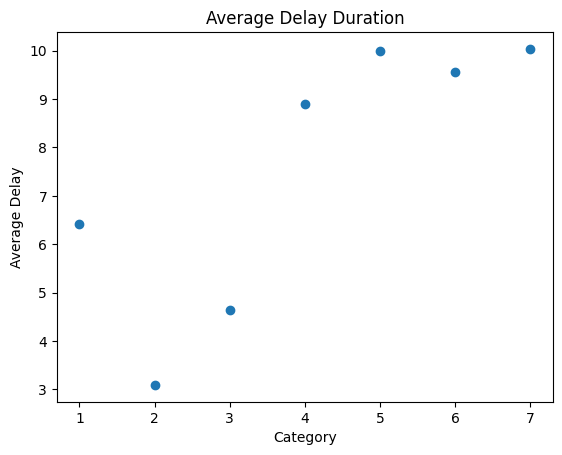

In [7]:
#using the automated function for ploting features against delay relation
flight_stats_day_week = summarize_delay_by(flights, "day_of_week")
Plotting_show = ploting_summarize(flight_stats_day_week,"scatter")

      arr_delay                   large_delay
          count       mean median        mean
month                                        
1           717  10.351464   -5.0    0.252441
2           709  -0.332863   -8.0    0.148096
3           828   7.925121   -5.0     0.22343
4           845   6.581065   -6.0    0.213018
5           823  12.844471   -3.0    0.246659
6           822  11.628954   -4.0     0.26399
7           882  21.494331   -0.5    0.318594
8           857   9.994166   -6.0    0.231039
9           831   0.935018   -8.0    0.154031
10          933  -3.619507  -10.0    0.118971
11          794   1.998741   -8.0     0.18262
12          795  10.394969   -5.0    0.232704


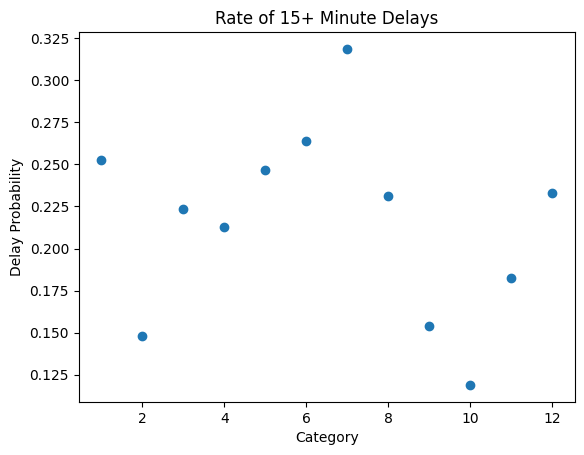

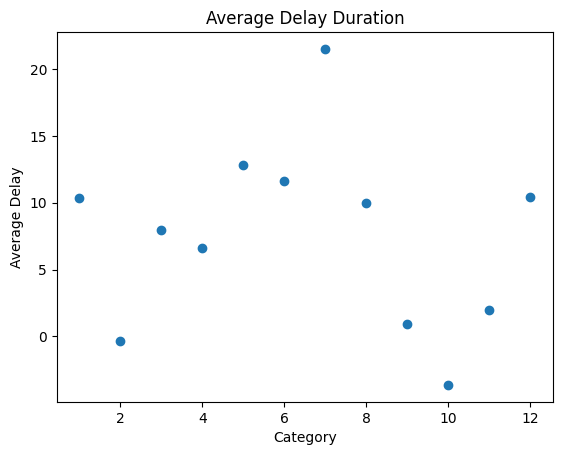

In [8]:
#using the automated function for ploting features against delay relation
flight_stats_day_month = summarize_delay_by(flights, "month")
Plotting_show = ploting_summarize(flight_stats_day_month,"scatter")

             arr_delay                  large_delay
                 count      mean median        mean
elapsed_hour                                       
0.0                285  8.950877   -4.0     0.17193
1.0               3973  7.267304   -6.0    0.204883
2.0               3150  7.735873   -7.0    0.219683
3.0               1325  9.423396   -5.0    0.249057
4.0                569  7.177504   -6.0    0.228471
5.0                376  4.260638   -8.0     0.18617
6.0                144  1.604167   -4.5    0.215278
7.0                  5  7.200000  -19.0         0.2
8.0                  4 -5.000000    3.5        0.25
9.0                  2 -2.000000   -2.0         0.0
10.0                 2  6.000000    6.0         0.5
11.0                 1 -6.000000   -6.0         0.0


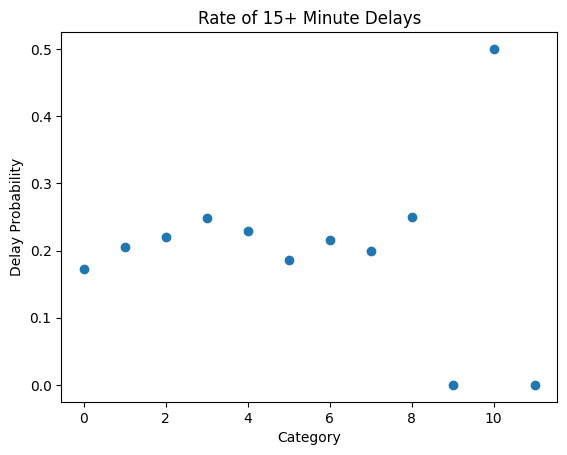

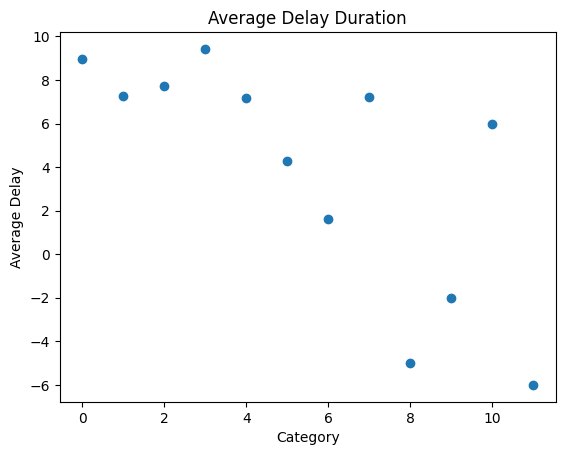

In [9]:
#print((flights["crs_elapsed_time"]).head(),(flights["crs_dep_time"]).head())
flights["elapsed_hour"] = (flights["crs_elapsed_time"] // 60)
#using the automated function for ploting features against delay relation
flight_stats_day_month = summarize_delay_by(flights, "elapsed_hour")
Plotting_show = ploting_summarize(flight_stats_day_month,"scatter")

       arr_delay                   large_delay
           count       mean median        mean
origin                                        
ATL          487   6.462012   -6.0    0.197125
AUS          129   8.620155   -4.0    0.224806
BNA          156  10.756410   -3.0        0.25
BOS          191   3.418848  -12.0    0.188482
BWI          135   6.414815   -3.0    0.259259
CLT          314  15.614650   -3.0     0.27707
DAL          103   2.281553   -7.0    0.213592
DCA          173   8.011561  -10.0    0.213873
DEN          408  10.149510   -5.0    0.279412
DFW          428  13.633178   -4.0    0.259346
DTW          190   6.273684   -7.5    0.173684
EWR          193   7.704663  -11.0     0.19171
FLL          149  12.476510   -2.0    0.268456
IAH          155  13.148387   -6.0    0.258065
JFK          191  -2.104712   -8.0    0.209424
LAS          230   8.747826   -3.5    0.273913
LAX          278   5.179856   -7.5    0.205036
LGA          229   3.912664  -14.0    0.170306
MCO          

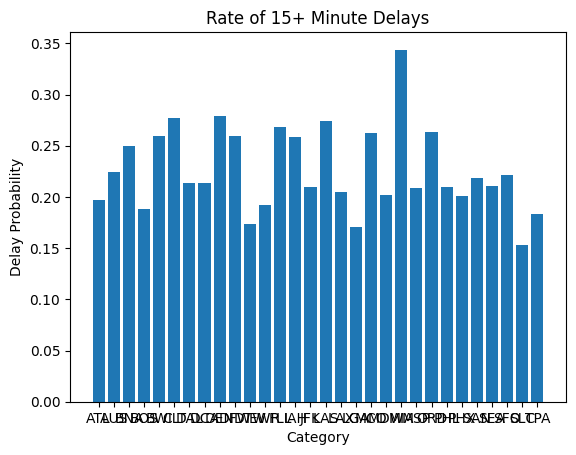

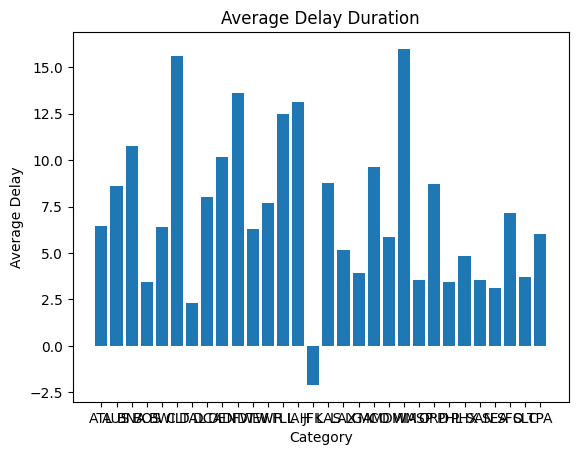

In [10]:
origin_flights = flights["origin"].value_counts()
popular_origin = origin_flights[origin_flights > 100].index
exp_origin = flights[flights["origin"].isin(popular_origin)].copy()
#using the automated function for ploting features against delay relation
flight_stats_day_month = summarize_delay_by(exp_origin, "origin")
Plotting_show = ploting_summarize(flight_stats_day_month,"bar")

     arr_delay                   large_delay
         count       mean median        mean
dest                                        
ATL        479   8.672234   -8.0    0.210856
AUS        140   4.557143   -5.0    0.264286
BNA        142   9.084507   -4.0    0.225352
BOS        183   5.978142   -8.0    0.245902
BWI        130   8.053846   -5.0    0.207692
CLT        281   8.854093   -4.0    0.256228
DAL        107   6.271028   -7.0     0.17757
DCA        188   3.702128   -8.0    0.191489
DEN        390   7.020513   -7.0    0.192308
DFW        439  13.517084   -5.0    0.273349
DTW        181   8.834254   -7.0    0.176796
EWR        172   6.186047   -9.5     0.22093
FLL        109   9.788991   -9.0    0.238532
IAH        159  12.628931   -9.0    0.194969
JFK        196  11.061224   -9.0    0.178571
LAS        277   5.660650   -6.0    0.216606
LAX        269   2.691450   -6.0    0.148699
LGA        210   3.476190  -10.0    0.209524
MCO        211   6.753555   -6.0    0.246445
MDW       

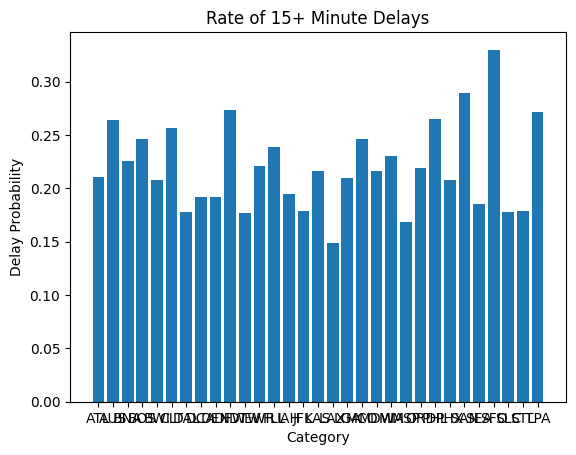

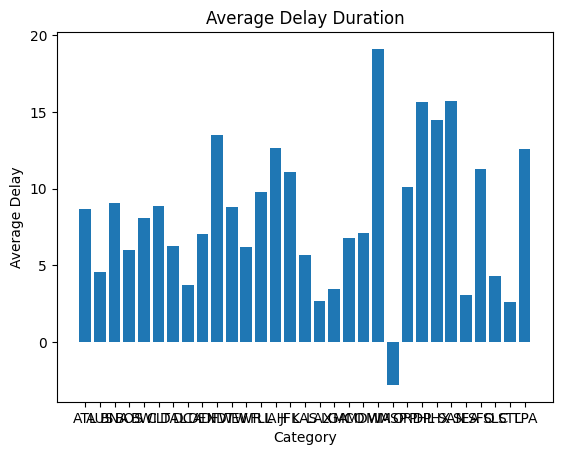

In [11]:
dest_flights = flights["dest"].value_counts()
popular_dest = dest_flights[dest_flights > 100].index
expirement_dest = flights[flights["dest"].isin(popular_dest)].copy()
#using the automated function for ploting features against delay relation
flight_stats_day_month = summarize_delay_by(expirement_dest, "dest")
Plotting_show = ploting_summarize(flight_stats_day_month,"bar")